### What Are Deep Agents?

Deep agents are a standalone library built on top of LangGraph that brings production-grade capabilities to LLM agents. Unlike simple agents that just loop between “think, act, observe,” deep agents come with built-in infrastructure for handling real-world complexity.

Here is what makes them different from a basic ReAct agent:

Planning -- Deep agents automatically break down complex tasks into subtasks using a built-in write_todos tool. Before diving into execution, they create a plan of attack.

File System for Context Management -- LLMs have limited context windows. Deep agents solve this by offloading large intermediate results (like search results or document content) into a virtual file system using write_file and read_file tools. This means they can handle tasks that produce far more data than a context window could hold.

Subagent Spawning -- For complex tasks, a deep agent can delegate subtasks to specialized subagents. Each subagent operates in its own context isolation, preventing the “context pollution” problem where unrelated information from one subtask confuses another.

Persistent Memory -- Deep agents can persist memory across conversations and threads, making them suitable for long-running tasks and multi-session workflows

### When Should You Use Deep Agents?

Use deep agents when your task involves any of these characteristics:

Multi-step complexity -- The task requires planning and decomposition, not just a single LLM call.

Large context requirements -- You need to process more information than fits in a single context window.

Work delegation -- Different parts of the task benefit from specialized handling by isolated subagents.

Persistent workflows -- You need memory that survives across conversations and threads.

In [3]:
## BAsic deep agent

import os
from dotenv import load_dotenv

load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")


In [4]:
from tavily import TavilyClient

tavily_client = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))

In [5]:
from typing import Literal

def web_search(query: str, max_results: int = 5, topic: Literal["sport", "news", "finance"]="general", include_raw_content: bool = False):
    """Run a web search"""
    return tavily_client.search(
        query,
        max_results,
        include_raw_content,
        topic,
    )

In [6]:
from langchain.chat_models import init_chat_model

model = init_chat_model("groq:qwen/qwen3-32b")
model

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x10bee36e0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10ca5e870>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'))

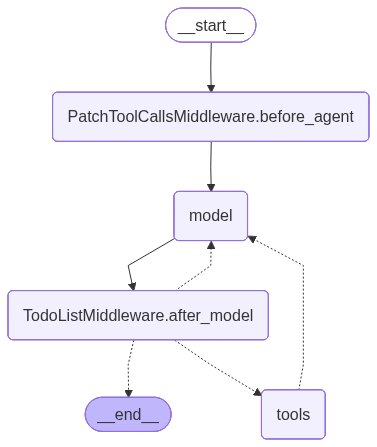

In [7]:
## Create a deep agent

## Prompt


## Agent

from deepagents import create_deep_agent

deepagent=create_deep_agent(
    model=model,
    tools=[web_search],
    system_prompt="Act as a researcher"
)
deepagent

In [9]:
result = deepagent.invoke({
    "messages": [
        {"role": "user",
         "content": "What is machine learning?"}
    ]
})

result

{'messages': [HumanMessage(content='What is machine learning?', additional_kwargs={}, response_metadata={}, id='ecb7d564-ad39-46ed-928e-c406b8956eff'),
  AIMessage(content='Machine learning is a subset of artificial intelligence (AI) that enables systems to learn patterns and make decisions from data without being explicitly programmed. It works by training algorithms on datasets to identify patterns, relationships, or trends, which are then used to make predictions or take actions on new, unseen data.\n\n### Key Concepts:\n1. **Supervised Learning**: Uses labeled data (input-output pairs) to train models. Examples include classification (e.g., spam detection) and regression (e.g., predicting house prices).\n2. **Unsupervised Learning**: Finds hidden patterns in unlabeled data. Examples include clustering (e.g., customer segmentation) and dimensionality reduction.\n3. **Reinforcement Learning**: Learns by interacting with an environment, receiving rewards or penalties for actions. Comm

In [10]:
result.get("messages", [])[-1].content

'Machine learning is a subset of artificial intelligence (AI) that enables systems to learn patterns and make decisions from data without being explicitly programmed. It works by training algorithms on datasets to identify patterns, relationships, or trends, which are then used to make predictions or take actions on new, unseen data.\n\n### Key Concepts:\n1. **Supervised Learning**: Uses labeled data (input-output pairs) to train models. Examples include classification (e.g., spam detection) and regression (e.g., predicting house prices).\n2. **Unsupervised Learning**: Finds hidden patterns in unlabeled data. Examples include clustering (e.g., customer segmentation) and dimensionality reduction.\n3. **Reinforcement Learning**: Learns by interacting with an environment, receiving rewards or penalties for actions. Common in game-playing AI (e.g., AlphaGo) or robotics.\n\n### Applications:\n- Image and speech recognition\n- Recommendation systems (e.g., Netflix, Amazon)\n- Fraud detection

In [11]:
result.get("files")